# Chapter 42 — Cross-Entropy for Next-Token Prediction

## Learning goals

Chapter 40 described next-token prediction as classification, and Chapter 41 converted vocabulary logits into probabilities with softmax.

This chapter turns the probability assigned to the correct next token into a scalar loss.

By the end of this chapter, you should be able to:

1. Explain one-example cross-entropy for next-token prediction.
2. Compute stable softmax probabilities from logits.
3. Locate the probability assigned to the correct token.
4. Compute negative log-likelihood from that probability.
5. Explain why higher target probability means lower loss.
6. Compute cross-entropy stably and directly from logits.
7. Explain the relationship between index and one-hot targets.
8. Plot loss as target and competitor logits change.
9. Average losses across examples or token positions.
10. Explain how one scalar loss leads to parameter gradients.
11. Connect average cross-entropy to perplexity.

## The one-position pipeline

At one token position, the model produces one logit per vocabulary token.

The training calculation is:

```text
logits → softmax probabilities → target-token probability → negative log → loss
```

For a single correct class, cross-entropy equals the negative log probability assigned to that class.

## Terms used in this chapter

- A **target token** is the token that actually follows the context in the training data.
- A **target token ID** is its integer vocabulary index.
- **Negative log-likelihood** is `-log(target probability)`.
- **Cross-entropy** is `-Σ qᵢ log(pᵢ)` for target distribution `q` and model distribution `p`.
- A **one-hot target** assigns 1 to the correct class and 0 to every other class.
- **Log-sum-exp** is a stable way to combine exponentials in log space.
- A **scalar loss** is one number summarizing prediction error.
- A **gradient** describes how that scalar changes with respect to an earlier value.

This notebook uses the natural logarithm, so losses are measured in **nats**.

## Set up one next-token example

The target is `dog`, whose token ID is 1 in this tiny vocabulary.

In [1]:
import math

possible_next_tokens = ["cat", "dog", "the", "."]
correct_next_token = "dog"
next_token_logits = [1.2, 3.5, 0.1, -0.7]

if len(possible_next_tokens) != len(next_token_logits):
    raise ValueError("There must be exactly one logit per possible token.")

correct_token_id = possible_next_tokens.index(correct_next_token)

print("Possible next tokens:", possible_next_tokens)
print("Correct next token:", correct_next_token)
print("Correct token ID:", correct_token_id)
print("Raw logits:", next_token_logits)

Possible next tokens: ['cat', 'dog', 'the', '.']
Correct next token: dog
Correct token ID: 1
Raw logits: [1.2, 3.5, 0.1, -0.7]


## Inspect token-logit alignment

Model code uses token IDs, so the same index must select a token, its logit, and later its probability.

In [2]:
print("token ID | token | raw logit | target?")
print("-" * 43)
for token_id, (token, logit) in enumerate(
    zip(possible_next_tokens, next_token_logits, strict=True)
):
    print(
        f"{token_id:>8} | {token:>5} | {logit:>9.4f} | "
        f"{str(token_id == correct_token_id):>7}"
    )

token ID | token | raw logit | target?
-------------------------------------------
       0 |   cat |    1.2000 |   False
       1 |   dog |    3.5000 |    True
       2 |   the |    0.1000 |   False
       3 |     . |   -0.7000 |   False


## Stable softmax

Subtracting the largest finite logit prevents unnecessary positive overflow without changing the mathematical probabilities.

In [3]:
def validate_logits(logits: list[float]) -> None:
    if not logits:
        raise ValueError("logits must not be empty.")

    if not all(math.isfinite(logit) for logit in logits):
        raise ValueError("Every logit must be finite.")


def validate_target_id(number_of_classes: int, target_id: int) -> None:
    if not 0 <= target_id < number_of_classes:
        raise ValueError("target_id is out of range.")


def stable_softmax(logits: list[float]) -> list[float]:
    validate_logits(logits)
    largest_logit = max(logits)
    shifted_exponentials = [math.exp(logit - largest_logit) for logit in logits]
    exponential_total = sum(shifted_exponentials)
    return [value / exponential_total for value in shifted_exponentials]


next_token_probabilities = stable_softmax(next_token_logits)

print("Softmax probabilities:", next_token_probabilities)
print("Probability sum:", sum(next_token_probabilities))

Softmax probabilities: [0.0872857624378235, 0.8706041202624649, 0.029054906334091433, 0.013055210965620201]
Probability sum: 1.0


## Validate the distribution

Floating-point sums are approximate, so numerical validation uses a tolerance.

In [4]:
def assert_valid_probability_distribution(
    probabilities: list[float],
    tolerance: float = 1e-12,
) -> None:
    if not probabilities:
        raise ValueError("probabilities must not be empty.")

    if not all(math.isfinite(probability) for probability in probabilities):
        raise ValueError("Every probability must be finite.")

    if not all(0.0 <= probability <= 1.0 for probability in probabilities):
        raise ValueError("Every probability must be between 0 and 1.")

    if not math.isclose(sum(probabilities), 1.0, abs_tol=tolerance):
        raise ValueError("Probabilities must sum to 1.")


assert_valid_probability_distribution(next_token_probabilities)

print("token | logit | probability | target?")
print("-" * 48)
for token_id, (token, logit, probability) in enumerate(
    zip(
        possible_next_tokens,
        next_token_logits,
        next_token_probabilities,
        strict=True,
    )
):
    print(
        f"{token:>5} | {logit:>6.2f} | {probability:>11.6f} | "
        f"{str(token_id == correct_token_id):>7}"
    )

token | logit | probability | target?
------------------------------------------------
  cat |   1.20 |    0.087286 |   False
  dog |   3.50 |    0.870604 |    True
  the |   0.10 |    0.029055 |   False
    . |  -0.70 |    0.013055 |   False


## Extract the target-token probability

The model distributes probability across every option, but this one-hot training example evaluates the probability at the target token ID.

In [5]:
correct_token_probability = next_token_probabilities[correct_token_id]

print("Correct next token:", correct_next_token)
print("Correct token ID:", correct_token_id)
print("Probability assigned to it:", correct_token_probability)

assert correct_token_probability == max(next_token_probabilities)

Correct next token: dog
Correct token ID: 1
Probability assigned to it: 0.8706041202624649


## Negative log-likelihood

The one-example loss is:

```text
loss = -log(target-token probability)
```

A probability near 1 produces a loss near 0, while a probability near 0 produces a large loss.

In [6]:
one_example_loss = -math.log(correct_token_probability)

print("Correct-token probability:", correct_token_probability)
print("Cross-entropy loss:", one_example_loss)
print("Loss type:", type(one_example_loss))

assert one_example_loss >= 0.0

Correct-token probability: 0.8706041202624649
Cross-entropy loss: 0.13856791720518152
Loss type: <class 'float'>


## Cross-entropy from probabilities

The probability-based helper makes the core idea explicit and rejects a zero target probability because `log(0)` is undefined.

In [7]:
def cross_entropy_from_probabilities(
    probabilities: list[float],
    target_id: int,
) -> float:
    assert_valid_probability_distribution(probabilities)
    validate_target_id(len(probabilities), target_id)
    target_probability = probabilities[target_id]

    if target_probability <= 0.0:
        raise ValueError("The target probability must be greater than zero.")

    return -math.log(target_probability)


probability_route_loss = cross_entropy_from_probabilities(
    next_token_probabilities,
    correct_token_id,
)

print("Probability-route loss:", probability_route_loss)
assert math.isclose(probability_route_loss, one_example_loss, rel_tol=1e-12)

Probability-route loss: 0.13856791720518152


## Why the negative logarithm has the right shape

The natural logarithm turns multiplication of sequence probabilities into addition of token losses and strongly penalizes tiny target probabilities.

The table below treats 1 as a conceptual endpoint; finite softmax logits with more than one class assign every class a mathematical probability strictly between 0 and 1.

In [8]:
example_target_probabilities = [1.0, 0.9, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001]

print("target probability | negative log loss")
print("-" * 39)
for example_probability in example_target_probabilities:
    print(f"{example_probability:>18.6f} | {-math.log(example_probability):>17.6f}")

target probability | negative log loss
---------------------------------------
          1.000000 |         -0.000000
          0.900000 |          0.105361
          0.750000 |          0.287682
          0.500000 |          0.693147
          0.250000 |          1.386294
          0.100000 |          2.302585
          0.010000 |          4.605170
          0.001000 |          6.907755


## Plot negative log loss

The curve approaches zero near target probability 1 and rises without bound as the probability approaches zero in exact mathematics.

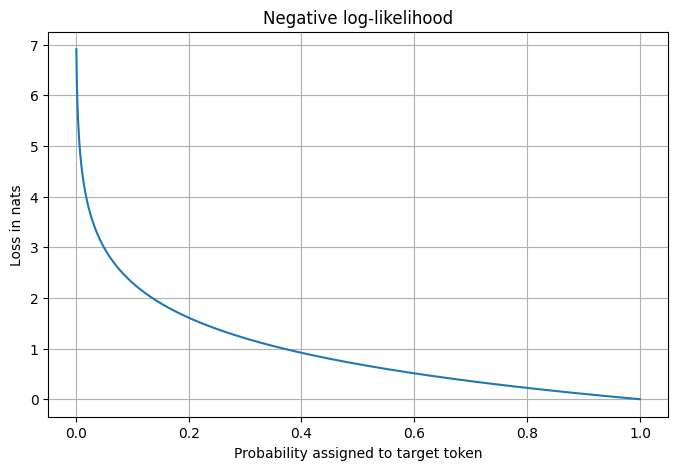

In [9]:
import matplotlib.pyplot as plt

probability_curve_values = [0.001 + step * 0.001 for step in range(1000)]
negative_log_curve_values = [
    -math.log(probability) for probability in probability_curve_values
]

plt.figure(figsize=(8, 5))
plt.plot(probability_curve_values, negative_log_curve_values)
plt.xlabel("Probability assigned to target token")
plt.ylabel("Loss in nats")
plt.title("Negative log-likelihood")
plt.grid(True)
plt.show()

## Good and bad predictions

Two models may use the same vocabulary and target while assigning very different probability to that target.

In [10]:
good_logits = [1.2, 3.5, 0.1, -0.7]
bad_logits = [3.5, -0.5, 2.0, 1.0]
good_probabilities = stable_softmax(good_logits)
bad_probabilities = stable_softmax(bad_logits)
good_loss = cross_entropy_from_probabilities(good_probabilities, correct_token_id)
bad_loss = cross_entropy_from_probabilities(bad_probabilities, correct_token_id)

print("Good target probability:", good_probabilities[correct_token_id])
print("Good loss:", good_loss)
print("Bad target probability:", bad_probabilities[correct_token_id])
print("Bad loss:", bad_loss)

assert good_probabilities[correct_token_id] > bad_probabilities[correct_token_id]
assert good_loss < bad_loss

Good target probability: 0.8706041202624649
Good loss: 0.13856791720518152
Bad target probability: 0.01383846822537223
Bad loss: 4.2803030122753025


## Compare good and bad distributions

The target token is highlighted in both panels, making the relationship between its bar height and the scalar loss visible.

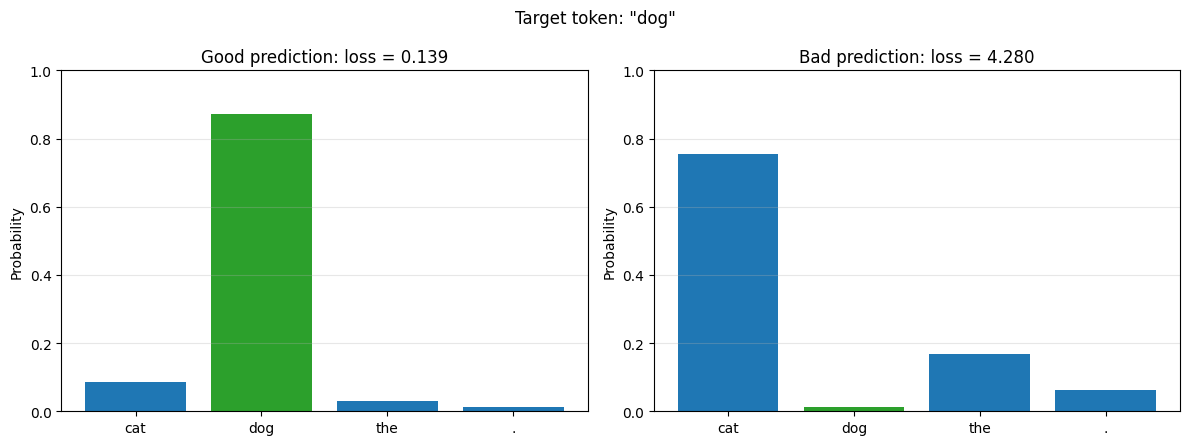

In [11]:
distribution_figure, distribution_axes = plt.subplots(1, 2, figsize=(12, 4.5))
distribution_colors = [
    "tab:green" if token_id == correct_token_id else "tab:blue"
    for token_id in range(len(possible_next_tokens))
]

distribution_axes[0].bar(
    possible_next_tokens,
    good_probabilities,
    color=distribution_colors,
)
distribution_axes[0].set_ylim(0.0, 1.0)
distribution_axes[0].set_ylabel("Probability")
distribution_axes[0].set_title(f"Good prediction: loss = {good_loss:.3f}")
distribution_axes[0].grid(True, axis="y", alpha=0.3)

distribution_axes[1].bar(
    possible_next_tokens,
    bad_probabilities,
    color=distribution_colors,
)
distribution_axes[1].set_ylim(0.0, 1.0)
distribution_axes[1].set_ylabel("Probability")
distribution_axes[1].set_title(f"Bad prediction: loss = {bad_loss:.3f}")
distribution_axes[1].grid(True, axis="y", alpha=0.3)

distribution_figure.suptitle('Target token: "dog"')
distribution_figure.tight_layout()
plt.show()

## Compute cross-entropy directly from logits

The intuitive route computes softmax and then takes the target probability's logarithm.

Numerical libraries usually combine those operations:

```text
loss = logsumexp(logits) - target_logit
```

Computing log-sum-exp with a maximum shift avoids both large positive exponentials and taking the logarithm of an underflowed target probability.

In [12]:
def stable_cross_entropy_from_logits(
    logits: list[float],
    target_id: int,
) -> float:
    validate_logits(logits)
    validate_target_id(len(logits), target_id)
    largest_logit = max(logits)
    shifted_exponential_total = sum(math.exp(logit - largest_logit) for logit in logits)
    log_sum_exp = largest_logit + math.log(shifted_exponential_total)
    return log_sum_exp - logits[target_id]


logit_route_loss = stable_cross_entropy_from_logits(
    next_token_logits,
    correct_token_id,
)

print("Probability-route loss:", probability_route_loss)
print("Stable logits-route loss:", logit_route_loss)

assert math.isclose(probability_route_loss, logit_route_loss, rel_tol=1e-12)

Probability-route loss: 0.13856791720518152
Stable logits-route loss: 0.1385679172051817


## The combined formula survives underflow

Stable softmax may round an extremely tiny target probability to zero in floating-point arithmetic.

The direct logits formula still returns the correct finite loss for finite logits.

In [13]:
extreme_logits = [0.0, -1000.0]
extreme_target_id = 1
extreme_probabilities = stable_softmax(extreme_logits)
extreme_stable_loss = stable_cross_entropy_from_logits(
    extreme_logits,
    extreme_target_id,
)

print("Extreme logits:", extreme_logits)
print("Floating-point probabilities:", extreme_probabilities)
print("Stable direct-from-logits loss:", extreme_stable_loss)

try:
    cross_entropy_from_probabilities(extreme_probabilities, extreme_target_id)
except ValueError as underflow_error:
    print("Probability route failed after underflow:", underflow_error)
else:
    raise AssertionError("The underflowed probability route should fail.")

assert extreme_probabilities[extreme_target_id] == 0.0
assert extreme_stable_loss == 1000.0

Extreme logits: [0.0, -1000.0]
Floating-point probabilities: [1.0, 0.0]
Stable direct-from-logits loss: 1000.0
Probability route failed after underflow: The target probability must be greater than zero.


## Prefer logits for cross-entropy APIs

Passing logits to a combined cross-entropy function is both simpler and more numerically stable.

Applying softmax first and then passing probabilities to a library function that expects logits would also apply the wrong formula.

Always check the API contract.

## Loss as the target logit changes

Hold every competing logit fixed while sweeping the target `dog` logit.

The target probability rises and the cross-entropy loss falls.

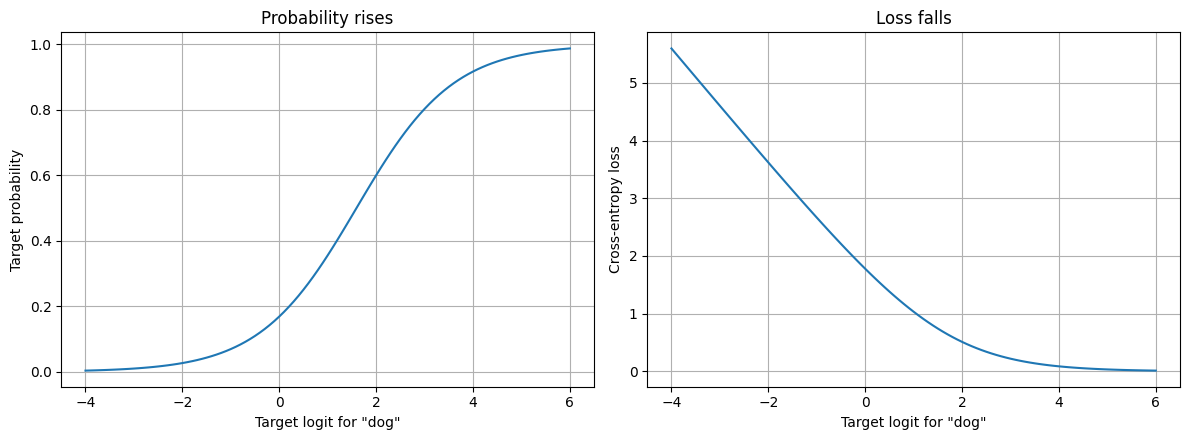

In [14]:
target_logit_values = [-4.0 + step * 0.1 for step in range(101)]
target_probability_values: list[float] = []
target_loss_values: list[float] = []

for target_logit in target_logit_values:
    swept_logits = [1.2, target_logit, 0.1, -0.7]
    swept_probabilities = stable_softmax(swept_logits)
    target_probability_values.append(swept_probabilities[correct_token_id])
    target_loss_values.append(
        stable_cross_entropy_from_logits(swept_logits, correct_token_id)
    )

score_figure, score_axes = plt.subplots(1, 2, figsize=(12, 4.5))
score_axes[0].plot(target_logit_values, target_probability_values)
score_axes[0].set_xlabel('Target logit for "dog"')
score_axes[0].set_ylabel("Target probability")
score_axes[0].set_title("Probability rises")
score_axes[0].grid(True)

score_axes[1].plot(target_logit_values, target_loss_values)
score_axes[1].set_xlabel('Target logit for "dog"')
score_axes[1].set_ylabel("Cross-entropy loss")
score_axes[1].set_title("Loss falls")
score_axes[1].grid(True)

score_figure.tight_layout()
plt.show()

assert target_loss_values[-1] < target_loss_values[0]

## Competitor logits also matter

Softmax compares all classes, so raising a competitor logit takes probability mass from the target and increases loss.

In [15]:
competitor_logit_values = [-2.0 + step * 0.1 for step in range(101)]
competitor_loss_values = [
    stable_cross_entropy_from_logits(
        [competitor_logit, 3.5, 0.1, -0.7],
        correct_token_id,
    )
    for competitor_logit in competitor_logit_values
]

print("Loss with low cat logit:", competitor_loss_values[0])
print("Loss with high cat logit:", competitor_loss_values[-1])

assert competitor_loss_values[-1] > competitor_loss_values[0]

Loss with low cat logit: 0.051126117722615216
Loss with high cat logit: 4.5115790294366285


## One-hot targets explain the name

For target distribution `q` and model distribution `p`, cross-entropy is:

```text
-Σᵢ qᵢ log(pᵢ)
```

A one-hot target has one entry equal to 1, so every other term vanishes and the expression reduces to `-log(p_target)`.

In [16]:
def make_one_hot_target(number_of_classes: int, target_id: int) -> list[float]:
    validate_target_id(number_of_classes, target_id)
    target_distribution = [0.0] * number_of_classes
    target_distribution[target_id] = 1.0
    return target_distribution


def cross_entropy_from_target_distribution(
    probabilities: list[float],
    target_distribution: list[float],
) -> float:
    assert_valid_probability_distribution(probabilities)
    assert_valid_probability_distribution(target_distribution)

    if len(probabilities) != len(target_distribution):
        raise ValueError("Both distributions must have the same length.")

    loss = 0.0

    for probability, target_weight in zip(
        probabilities,
        target_distribution,
        strict=True,
    ):
        if target_weight > 0.0:
            if probability <= 0.0:
                raise ValueError(
                    "Positive target weight requires positive probability."
                )
            loss -= target_weight * math.log(probability)

    return loss


one_hot_target = make_one_hot_target(len(possible_next_tokens), correct_token_id)
one_hot_loss = cross_entropy_from_target_distribution(
    next_token_probabilities,
    one_hot_target,
)

print("One-hot target:", one_hot_target)
print("Index-target loss:", probability_route_loss)
print("One-hot-target loss:", one_hot_loss)

assert math.isclose(one_hot_loss, probability_route_loss, rel_tol=1e-12)

One-hot target: [0.0, 1.0, 0.0, 0.0]
Index-target loss: 0.13856791720518152
One-hot-target loss: 0.13856791720518152


## Index targets are usually more compact

For one correct token among a large vocabulary, storing one integer target ID avoids constructing a mostly-zero vector.

The one-hot representation remains useful for understanding the formula and for target distributions that are not one-hot.

## The model receives one scalar loss

The model emits many logits and contains many parameters, but this one example produces one scalar loss.

Backpropagation starts from that scalar and applies the chain rule to compute a gradient for every parameter that influenced it.

The loss does not directly contain commands such as “increase weight 7”; gradients provide those local directions.

## Preview the score directions

Perturbing the target logit upward lowers loss, while perturbing a competitor upward raises loss.

The next chapter will connect this behavior to exact gradients.

In [17]:
baseline_loss = stable_cross_entropy_from_logits(next_token_logits, correct_token_id)
perturbation_size = 0.1

print("token | loss after +0.1 logit | loss change")
print("-" * 50)
for perturbed_id, token in enumerate(possible_next_tokens):
    perturbed_logits = list(next_token_logits)
    perturbed_logits[perturbed_id] += perturbation_size
    perturbed_loss = stable_cross_entropy_from_logits(
        perturbed_logits,
        correct_token_id,
    )
    loss_change = perturbed_loss - baseline_loss
    print(f"{token:>5} | {perturbed_loss:>21.6f} | {loss_change:>11.6f}")

    if perturbed_id == correct_token_id:
        assert loss_change < 0.0
    else:
        assert loss_change > 0.0

token | loss after +0.1 logit | loss change
--------------------------------------------------
  cat |              0.147706 |    0.009138
  dog |              0.126178 |   -0.012390
  the |              0.141619 |    0.003051
    . |              0.139940 |    0.001372


## Average over several token positions

Language-model training computes a loss at each selected position and usually averages those losses into one scalar batch objective.

In [18]:
dataset_contexts = ["the friendly", "a small", "walked to"]
dataset_target_ids = [1, 0, 3]
dataset_logits = [
    [0.2, 2.5, -0.4, -1.0],
    [1.8, 0.9, -0.2, -0.5],
    [0.3, 0.1, -0.5, 1.2],
]

if not (len(dataset_contexts) == len(dataset_target_ids) == len(dataset_logits)):
    raise ValueError("Dataset fields must have the same length.")

position_losses: list[float] = []

print("context | target | loss")
print("-" * 39)
for context, target_id, position_logits in zip(
    dataset_contexts,
    dataset_target_ids,
    dataset_logits,
    strict=True,
):
    position_loss = stable_cross_entropy_from_logits(position_logits, target_id)
    position_losses.append(position_loss)
    print(
        f"{context:>12} | {possible_next_tokens[target_id]:>6} | {position_loss:>8.5f}"
    )

average_cross_entropy = sum(position_losses) / len(position_losses)

print("Average cross-entropy:", average_cross_entropy)
assert average_cross_entropy > 0.0

context | target | loss
---------------------------------------
the friendly |    dog |  0.17015
     a small |    cat |  0.49601
   walked to |      . |  0.65343
Average cross-entropy: 0.43986433588848034


## Sequence and batch reduction

For a sequence, each target position contributes a vocabulary-sized logit vector and one target token ID.

Training code commonly averages over all non-masked positions in a batch.

Padding or intentionally ignored positions require a mask so they do not contribute to the average; later tensor chapters will implement this shape-aware reduction.

## Cross-entropy and perplexity

When natural logarithms are used, token-level perplexity is the exponential of average cross-entropy.

In [19]:
dataset_perplexity = math.exp(average_cross_entropy)

print("Average cross-entropy:", average_cross_entropy)
print("Perplexity:", dataset_perplexity)

assert dataset_perplexity >= 1.0

Average cross-entropy: 0.43986433588848034
Perplexity: 1.5524965861540354


## A clean one-example pipeline

The preferred compact path starts with logits and a target ID, computes stable cross-entropy directly, and uses softmax only when probabilities are needed for inspection.

In [20]:
pipeline_tokens = ["cat", "dog", "the", "."]
pipeline_logits = [1.2, 3.5, 0.1, -0.7]
pipeline_target_id = 1
pipeline_probabilities = stable_softmax(pipeline_logits)
pipeline_loss = stable_cross_entropy_from_logits(
    pipeline_logits,
    pipeline_target_id,
)

print("token | logit | probability | target?")
print("-" * 48)
for pipeline_token_id, (
    pipeline_token,
    pipeline_logit,
    pipeline_probability,
) in enumerate(
    zip(
        pipeline_tokens,
        pipeline_logits,
        pipeline_probabilities,
        strict=True,
    )
):
    print(
        f"{pipeline_token:>5} | {pipeline_logit:>6.2f} | "
        f"{pipeline_probability:>11.6f} | "
        f"{str(pipeline_token_id == pipeline_target_id):>7}"
    )

print("Target token:", pipeline_tokens[pipeline_target_id])
print("Target probability:", pipeline_probabilities[pipeline_target_id])
print("Cross-entropy loss:", pipeline_loss)

token | logit | probability | target?
------------------------------------------------
  cat |   1.20 |    0.087286 |   False
  dog |   3.50 |    0.870604 |    True
  the |   0.10 |    0.029055 |   False
    . |  -0.70 |    0.013055 |   False
Target token: dog
Target probability: 0.8706041202624649
Cross-entropy loss: 0.1385679172051817


## What not to do

- Do not treat raw logits as probabilities.
- Do not use the probability of the predicted token when the target token is different.
- Do not forget the negative sign in `-log(target probability)`.
- Do not take `log(0)` after a tiny probability underflows.
- Do not apply softmax before a library cross-entropy function that expects logits.
- Do not sum token losses when the intended objective is their mean without accounting for the changed scale.
- Do not include padded or ignored positions in the average.
- Do not expect the scalar loss itself to name parameter updates; gradients provide that information.

## Gotchas

### Cross-entropy uses the target class

The argmax class matters for accuracy, but the loss always indexes the dataset target.

### High target probability means low loss

Negative log-likelihood decreases toward zero as target probability rises toward one.

### All logits compete

Raising a competitor can increase loss even when the target logit does not change.

### Stable combined computation matters

`logsumexp(logits) - target_logit` avoids taking a logarithm of an underflowed probability.

### Reduction creates the training scalar

Many position losses are usually averaged into one scalar before backpropagation.

## Takeaways

For one next-token example:

```text
logits
→ softmax probabilities
→ probability at target token ID
→ -log(target probability)
→ scalar cross-entropy loss
```

The intuitive formula is `-log(p_target)`.

The numerically preferred logits formula is:

```text
logsumexp(logits) - target_logit
```

Higher target probability gives lower loss, while higher competing logits can increase loss.

Language-model training averages this loss over selected token positions and backpropagates from the resulting scalar.

## What comes next

The next chapter examines cross-entropy gradients with respect to logits.

It will show precisely why the gradient tends to raise the correct-token logit and lower competing logits during gradient descent.